# Phase 1.1 — Manipulator: decoupling matrix A(x) invertibility check

This notebook is **fully self-contained**: it (i) states the two-link manipulator system, (ii) derives $A(\bm x) = J(\bm x) M^{-1}(x_2)$ and $\det A \propto \sin x_2$ symbolically (SymPy) and provides a Python evaluator validated against it, and (iii) over the **chosen synthesis region** $\mathcal X_S^{\rm eff}$ confirms $\sigma_{\min}(A) \ge \epsilon$ on $\mathcal X_S\setminus\mathcal X_T$, visualizes the output-space coverage, and writes `phase1_1_outputs_manipulator.json`.

No main-repo data or code is read at runtime; all inputs are generated here and all outputs go to `revision/data/`.

$\mathcal X_S^{\rm eff}$ uses the elbow margin $0.3$ and full shoulder range $[-\pi,\pi]$: this covers ~99% of the reachable safe set (vs ~17% for the original paper box $x_2\in[0.8,\pi-0.8]$) while keeping $A$ well clear of its singular directions $x_2\in\{0,\pi\}$. Only this optimal region is reported below.


## 0. Parameters

All parameters used in this notebook.

### Model (two-link manipulator)

| Parameter     | Symbol           | Value         |
| ------------- | ---------------- | ------------- |
| link masses   | $m_1, m_2$       | $1.0,\ 1.0$   |
| link lengths  | $l_1, l_2$       | $4.0,\ 4.0$   |
| COM distances | $l_{c1}, l_{c2}$ | $2.0,\ 2.0$   |
| link inertias | $I_1, I_2$       | $0.02,\ 0.02$ |
| gravity       | $g$              | $9.81$        |

### State / output / sets

| Item       | Definition                                                                     |
| ---------- | ------------------------------------------------------------------------------ |
| state      | $\bm x=(x_1,x_2,x_3,x_4,x_5)=(q_1,q_2,\dot q_1,\dot q_2,q_1{+}q_2)$            |
| manifold   | $x_5 = x_1 + x_2$                                                              |
| input      | $\bm u=(\tau_1,\tau_2)$                                                        |
| output     | $\bm y=(l_1\cos x_1 + l_2\cos x_5,\ l_1\sin x_1 + l_2\sin x_5)$ (end-effector) |
| safe set   | $\mathrm{safe}(\bm y)=-(4(y_1-2)-2y_2^3)^2+0.8 y_2^3+10 \ge 0$                 |
| target set | $((y_1-5.5)/1.2)^2+((y_2-1.8)/0.4)^2-2 \le 0$ (ellipse centered $(5.5,1.8)$)   |

### Sampling region $\mathcal X_S^{\rm eff}$ and check parameters

Sampling is over the full 4D free state box $(x_1,x_2,x_3,x_4)$ with $x_5=x_1+x_2$.

| Parameter               | Symbol     | Value                                                    |
| ----------------------- | ---------- | -------------------------------------------------------- |
| shoulder range          | $x_1$      | $[-\pi,\ \pi]$                                           |
| elbow range             | $x_2$      | $[0.3,\ \pi-0.3]$ (margin $0.3$ from $\{0,\pi\}$)        |
| joint-velocity ranges   | $x_3, x_4$ | $[-0.5,\ 0.5]$ (sampled; $A$ & safe independent of them) |
| redundant coordinate    | $x_5$      | $x_1 + x_2$                                              |
| sample count            | $N$        | $80000$                                                  |
| RNG seed                | —          | $42$                                                     |
| invertibility threshold | $\epsilon$ | $10^{-2}$                                                |
| coverage grid           | —          | $400\times400$ over $(x_1,x_2)$                          |

Samples are generated here (NumPy) and $A$ is evaluated analytically; the analytic evaluator is validated against the in-notebook symbolic $A$. The original paper box was $x_1\in[-2,0.5]$, $x_2\in[0.8,\pi-0.8]$ (covered only ~17% of the reachable safe set); it is mentioned only for contrast.


## 1. System and decoupling matrix

**Lagrangian dynamics** $M(q_2)\ddot{\bm q} + C(q,\dot q)\dot{\bm q} + G = \bm u$, written in control-affine form $\dot{\bm x} = \bm f(\bm x) + \bm g(\bm x)\bm u$ with

$$
M(x_2) = \begin{bmatrix} I_1{+}I_2{+}m_1 l_{c1}^2 + m_2(l_1^2 + l_{c2}^2 + 2 l_1 l_{c2}\cos x_2) & m_2(l_{c2}^2 + l_1 l_{c2}\cos x_2) + I_2 \\ m_2(l_{c2}^2 + l_1 l_{c2}\cos x_2) + I_2 & m_2 l_{c2}^2 + I_2 \end{bmatrix},
\quad
\bm g(\bm x) = \begin{bmatrix} 0_{2\times 2} \\ M^{-1}(x_2) \\ 0_{1\times 2} \end{bmatrix}.
$$

**Decoupling matrix** (relative degree $\rho=2$, $\bm y^{(2)} = A(\bm x)\bm u + \bm b(\bm x)$): with end-effector Jacobian

$$
J(\bm x) = \begin{bmatrix} -l_1\sin x_1 - l_2\sin x_5 & -l_2\sin x_5 \\ l_1\cos x_1 + l_2\cos x_5 & l_2\cos x_5 \end{bmatrix},
\qquad
\boxed{\,A(\bm x) = J(\bm x)\, M^{-1}(x_2)\,}.
$$

Since $\det J = l_1 l_2 \sin(x_5 - x_1) = l_1 l_2 \sin x_2$ (on the manifold $x_5 = x_1 + x_2$) and $\det M(x_2) > 0$,

$$
\det A(\bm x) = \frac{l_1 l_2 \sin x_2}{\det M(x_2)} \propto \sin x_2,
$$

so $A$ is singular only at $\sin x_2 = 0 \Leftrightarrow x_2 \in \{0, \pi\}$ (fully extended / folded). The SymPy cell below re-derives this; the Python evaluator used afterwards is validated against the symbolic $A$.


In [19]:
import sympy as sp
from IPython.display import display, Math

x1, x2, x3, x4, x5 = sp.symbols("x1 x2 x3 x4 x5", real=True)
xs = sp.Matrix([x1, x2, x3, x4, x5])

# parameters (two-link manipulator)
m1, m2 = 1, 1
l1, l2 = 4, 4
lc1, lc2 = 2, 2
I1, I2 = sp.Rational(2, 100), sp.Rational(2, 100)
g = sp.Rational(981, 100)

M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * sp.cos(x2))
M12 = m2 * (lc2**2 + l1 * lc2 * sp.cos(x2)) + I2
M22 = m2 * lc2**2 + I2
M = sp.Matrix([[M11, M12], [M12, M22]])
Minv = M.inv()
C = sp.Matrix(
    [
        [-m2 * l1 * lc2 * sp.sin(x2) * x4, -m2 * l1 * lc2 * sp.sin(x2) * (x3 + x4)],
        [m2 * l1 * lc2 * sp.sin(x2) * x3, 0],
    ]
)
Gvec = sp.Matrix(
    [
        (m1 * g * lc1 + m2 * g * l1) * sp.cos(x1) + m2 * g * lc2 * sp.cos(x5),
        m2 * g * lc2 * sp.cos(x5),
    ]
)

qdot = sp.Matrix([x3, x4])
f = sp.Matrix.vstack(qdot, Minv * (-C * qdot - Gvec), sp.Matrix([x3 + x4]))
gx = sp.Matrix.vstack(sp.zeros(2, 2), Minv, sp.zeros(1, 2))
h = sp.Matrix([l1 * sp.cos(x1) + l2 * sp.cos(x5), l1 * sp.sin(x1) + l2 * sp.sin(x5)])

# A(x) = d(yddot)/du; the 2x2 sub-Jacobian of ydot wrt (x3, x4) equals J
ydot = h.jacobian(xs) * f
A_sym = sp.simplify(ydot.jacobian(xs) * gx)
det_M = sp.simplify(M.det())

# With x5 treated as a free symbol, det A is proportional to sin(x5 - x1).
det_A_free = sp.simplify(A_sym.det())

# The manifold x5 = x1 + x2 must be substituted before sin(x5 - x1) collapses to sin(x2).
det_A = sp.simplify(det_A_free.subs(x5, x1 + x2))
ratio = sp.simplify(
    det_A * det_M / (l1 * l2 * sp.sin(x2))
)  # expected = 1 on the manifold

display(Math(r"\det A(\boldsymbol x)\big|_{x_5\text{ free}} = " + sp.latex(det_A_free)))
display(Math(r"\det A(\boldsymbol x)\big|_{x_5 = x_1 + x_2} = " + sp.latex(det_A)))
display(
    Math(
        r"\det A \cdot \det M\,/\,(l_1 l_2 \sin x_2)\big|_{x_5 = x_1 + x_2} = "
        + sp.latex(ratio)
        + r" \quad (\text{expected } 1)"
    )
)

# callable form of A on the manifold x5 = x1 + x2, used to validate the Python evaluator below
A_sym_fun = sp.lambdify((x1, x2), A_sym.subs(x5, x1 + x2), "numpy")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. Setup, analytic $A$ evaluator, and validation against the symbolic $A$

`A_metrics` evaluates $A(\bm x) = J M^{-1}$ and its conditioning in vectorized form (2x2 closed-form SVD). It is validated by reproducing $\sigma_{\min}$ from the in-notebook symbolic $A$ (NumPy SVD of `A_sym_fun`) at random samples; the max difference should be ~machine epsilon.


In [20]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np

HERE = os.path.abspath(os.getcwd())
ROOT = HERE
for _ in range(5):
    if os.path.isdir(os.path.join(ROOT, "revision")):
        break
    ROOT = os.path.dirname(ROOT)
REV_DATA = os.path.join(ROOT, "revision", "data")
os.makedirs(REV_DATA, exist_ok=True)

# model parameters
L1, L2 = 4.0, 4.0
MM1, MM2 = 1.0, 1.0
LC1, LC2 = 2.0, 2.0
II1, II2 = 0.02, 0.02


def fk(x1, x2):
    x5 = x1 + x2
    return L1 * np.cos(x1) + L2 * np.cos(x5), L1 * np.sin(x1) + L2 * np.sin(x5)


def safe_poly(y1, y2):
    return -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10


def target_poly(y1, y2):
    return ((y1 - 5.5) ** 2 / 1.2**2) + ((y2 - 1.8) ** 2 / 0.4**2) - 2


def A_metrics(x1, x2):
    """Return (|det A|, sigma_min(A), cond(A)) for A = J(x) Minv(x2), vectorized."""
    x1 = np.asarray(x1, float)
    x2 = np.asarray(x2, float)
    x5 = x1 + x2
    cos2 = np.cos(x2)
    M11 = II1 + II2 + MM1 * LC1**2 + MM2 * (L1**2 + LC2**2 + 2 * L1 * LC2 * cos2)
    M12 = MM2 * (LC2**2 + L1 * LC2 * cos2) + II2
    M22 = (MM2 * LC2**2 + II2) * np.ones_like(x2)
    detM = M11 * M22 - M12**2
    iM11, iM12, iM22 = M22 / detM, -M12 / detM, M11 / detM  # Minv (symmetric)
    J11 = -L1 * np.sin(x1) - L2 * np.sin(x5)
    J12 = -L2 * np.sin(x5)
    J21 = L1 * np.cos(x1) + L2 * np.cos(x5)
    J22 = L2 * np.cos(x5)
    A11 = J11 * iM11 + J12 * iM12
    A12 = J11 * iM12 + J12 * iM22
    A21 = J21 * iM11 + J22 * iM12
    A22 = J21 * iM12 + J22 * iM22
    detA = A11 * A22 - A12 * A21
    frob2 = A11**2 + A12**2 + A21**2 + A22**2
    disc = np.sqrt(np.maximum(frob2**2 - 4 * detA**2, 0.0))
    sig_min = np.sqrt(np.maximum((frob2 - disc) / 2, 0.0))
    sig_max = np.sqrt((frob2 + disc) / 2)
    return np.abs(detA), sig_min, sig_max / np.maximum(sig_min, 1e-300)


# validate A_metrics against the in-notebook symbolic A (NumPy SVD of A_sym_fun)
_rng_val = np.random.default_rng(0)
_vx1 = _rng_val.uniform(-np.pi, np.pi, 2000)
_vx2 = _rng_val.uniform(0.2, np.pi - 0.2, 2000)
_, _sm, _ = A_metrics(_vx1, _vx2)
_sm_sym = np.array(
    [np.linalg.svd(A_sym_fun(a, b), compute_uv=False).min() for a, b in zip(_vx1, _vx2)]
)
print(f"ROOT = {ROOT}")
print(
    f"A_metrics vs symbolic A (2000 samples): max|sigma_min diff| = "
    f"{np.abs(_sm - _sm_sym).max():.2e}  (should be ~0)"
)

ROOT = /home/jianqiang/Downloads/reach_avoid_backstepping_MPC
A_metrics vs symbolic A (2000 samples): max|sigma_min diff| = 6.79e-15  (should be ~0)


## 3. Invertibility over $\mathcal X_S^{\rm eff}$

Sample the **genuine 4D state box** $(x_1,x_2,x_3,x_4)$ (with $x_5=x_1+x_2$ on the manifold), keep $\mathcal X_S\setminus\mathcal X_T$ (in safe, not in target), and confirm $\sigma_{\min}(A)\ge\epsilon$ everywhere. The candidates are full-state points (reused by Phase 1.2/1.3 and the success sampling, which all operate on the full state).

$A(\bm x)$ and safe-set membership both depend only on $(x_1,x_2)$ (velocities do not enter $A=JM^{-1}$ and the output is a position), so the invertibility numbers are velocity-independent — but the sampling is over the real 4D set, not a $(x_1,x_2)$ slice with the velocity channels fixed. Coverage of the reachable safe set is computed on a dense $(x_1,x_2)$ grid (an output-space property).


In [21]:
# chosen synthesis region X_S_eff, sampled over the genuine 4D free state box (x1,x2,x3,x4); x5 = x1 + x2
MARGIN = 0.3
X1_LO, X1_HI = -np.pi, np.pi
X2_LO, X2_HI = MARGIN, np.pi - MARGIN
X3_LO, X3_HI = -0.5, 0.5  # q1dot bounds
X4_LO, X4_HI = -0.5, 0.5  # q2dot bounds
EPS = 1e-2
N_SAMPLES = 80000
SEED = 42

rng = np.random.default_rng(SEED)
sx1 = rng.uniform(X1_LO, X1_HI, N_SAMPLES)
sx2 = rng.uniform(X2_LO, X2_HI, N_SAMPLES)
sx3 = rng.uniform(X3_LO, X3_HI, N_SAMPLES)
sx4 = rng.uniform(X4_LO, X4_HI, N_SAMPLES)
sx5 = sx1 + sx2  # manifold
state = np.column_stack(
    [sx1, sx2, sx3, sx4, sx5]
)  # full-state samples (5 cols, x5 derived)

sy1, sy2 = fk(sx1, sx2)
in_safe = safe_poly(sy1, sy2) >= 0
in_RA = in_safe & (target_poly(sy1, sy2) > 0)  # X_S \ X_T
cand = state[
    in_RA
]  # full-state X_S\X_T candidates (reused downstream by Phase 1.2/1.3)

# A(x) and safe-set membership are independent of (x3, x4); A_metrics uses (x1, x2)
absdet_RA, sig_RA, cond_RA = A_metrics(cand[:, 0], cand[:, 1])

# coverage of the reachable safe set (output depends only on (x1, x2); dense grid)
x1g = np.linspace(-np.pi, np.pi, 400)
x2g = np.linspace(0.02, np.pi - 0.02, 400)
GX1, GX2 = np.meshgrid(x1g, x2g)
GY1, GY2 = fk(GX1, GX2)
reach_safe = safe_poly(GY1, GY2) >= 0
cover_pct = (
    100 * (reach_safe & (GX2 >= X2_LO) & (GX2 <= X2_HI)).sum() / reach_safe.sum()
)

min_sigma = float(sig_RA.min())
frac_RA = float(in_RA.mean())
n_needed = int(np.ceil(500 / max(frac_RA, 1e-9)) / 1000) * 1000

print(
    f"X_S_eff (4D state box): x1 in [{X1_LO:.3f}, {X1_HI:.3f}], x2 in [{X2_LO:.3f}, {X2_HI:.3f}], "
    f"x3 in [{X3_LO}, {X3_HI}], x4 in [{X4_LO}, {X4_HI}], x5 = x1 + x2"
)
print(f"coverage of reachable safe set: {cover_pct:.1f}%")
print(
    f"X_S\\X_T candidates: {cand.shape[0]} full-state points / {N_SAMPLES}  ({100*frac_RA:.1f}% of box) "
    f"-> ~{n_needed} samples for >=500 candidates"
)
print(
    f"X_S\\X_T |det A|:   min={absdet_RA.min():.4f}, median={np.median(absdet_RA):.4f}"
)
print(
    f"X_S\\X_T sigma_min: min={min_sigma:.4f}  (epsilon={EPS:.0e}),  max cond={cond_RA.max():.1f}"
)
print(f"all sigma_min >= epsilon over X_S\\X_T ? {bool((sig_RA >= EPS).all())}")
print(
    "(A and safe membership are independent of x3, x4; sampling is over the full 4D state.)"
)

X_S_eff (4D state box): x1 in [-3.142, 3.142], x2 in [0.300, 2.842], x3 in [-0.5, 0.5], x4 in [-0.5, 0.5], x5 = x1 + x2
coverage of reachable safe set: 98.7%
X_S\X_T candidates: 3632 full-state points / 80000  (4.5% of box) -> ~11000 samples for >=500 candidates
X_S\X_T |det A|:   min=0.2030, median=0.2411
X_S\X_T sigma_min: min=0.0683  (epsilon=1e-02),  max cond=46.0
all sigma_min >= epsilon over X_S\X_T ? True
(A and safe membership are independent of x3, x4; sampling is over the full 4D state.)


## 4. Output-space coverage colored by $|\det A|$

$\mathcal X_S\setminus\mathcal X_T$ samples mapped to the end-effector plane, colored by $|\det A|$, with the safe boundary (red) and target boundary (green). The color (tracking $\det A \propto \sin x_2$) stays well away from $0$ across the whole covered region.


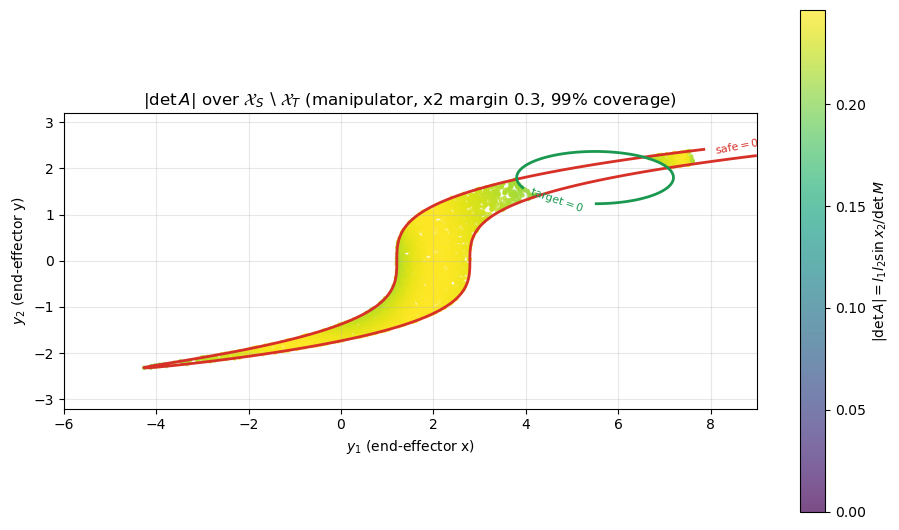

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
sc = ax.scatter(
    sy1[in_RA], sy2[in_RA], c=absdet_RA, s=6, cmap="viridis", vmin=0, alpha=0.7
)
plt.colorbar(sc, ax=ax, label=r"$|\det A| = l_1 l_2 \sin x_2 / \det M$")
byy1 = np.linspace(-6, 9, 600)
byy2 = np.linspace(-3.2, 3.2, 600)
BY1, BY2 = np.meshgrid(byy1, byy2)
cs_s = ax.contour(
    BY1, BY2, safe_poly(BY1, BY2), levels=[0], colors="#d73027", linewidths=2
)
cs_t = ax.contour(
    BY1, BY2, target_poly(BY1, BY2), levels=[0], colors="#1a9850", linewidths=2
)
ax.clabel(cs_s, fmt={0: r"safe$=0$"}, fontsize=8)
ax.clabel(cs_t, fmt={0: r"target$=0$"}, fontsize=8)
ax.set_xlabel(r"$y_1$ (end-effector x)")
ax.set_ylabel(r"$y_2$ (end-effector y)")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.set_title(
    rf"$|\det A|$ over $\mathcal{{X}}_S\setminus\mathcal{{X}}_T$ "
    rf"(manipulator, x2 margin {MARGIN}, {cover_pct:.0f}% coverage)"
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "detA_manipulator_output_space.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## 5. Verdict

$\min_{\mathcal X_S\setminus\mathcal X_T}\sigma_{\min}(A) \ge \epsilon$ → **PASS**, set $\mathcal X_S^{\rm eff}$ as the chosen region.


In [23]:
verdict = "PASS" if min_sigma >= EPS else "NEEDS_SHRINK"
print(f"VERDICT: {verdict}")
print(f"  min sigma_min over X_S\\X_T = {min_sigma:.4e}  (epsilon = {EPS:.2e})")
print(f"  safe-set coverage = {cover_pct:.1f}%   (x2 margin {MARGIN}, x1 in [-pi, pi])")

VERDICT: PASS
  min sigma_min over X_S\X_T = 6.8255e-02  (epsilon = 1.00e-02)
  safe-set coverage = 98.7%   (x2 margin 0.3, x1 in [-pi, pi])


## 6. Export JSON

`X_S_eff_def` is the chosen synthesis region; Phase 1.2 reads only this field.


In [24]:
out = {
    "phase": "1.1",
    "example": "manipulator",
    "system": {
        "state": ["x1=q1", "x2=q2", "x3=q1dot", "x4=q2dot", "x5=q1+q2"],
        "manifold": "x5 = x1 + x2",
        "input": ["u1 = tau1", "u2 = tau2"],
        "output": "y = (l1*cos(x1)+l2*cos(x5), l1*sin(x1)+l2*sin(x5))  [end-effector]",
        "params": {
            "m1": 1.0,
            "m2": 1.0,
            "l1": 4.0,
            "l2": 4.0,
            "lc1": 2.0,
            "lc2": 2.0,
            "I1": 0.02,
            "I2": 0.02,
            "g": 9.81,
        },
        "safe_set": "-(4*(y1-2)-2*y2**3)**2 + 0.8*y2**3 + 10 >= 0",
        "target_set": "((y1-5.5)/1.2)**2 + ((y2-1.8)/0.4)**2 - 2 <= 0",
        "A_matrix": "A(x) = J(x) * Minv(x2)",
        "det_A": "l1*l2*sin(x2) / det M(x2)  (proportional to sin(x2))",
    },
    "epsilon": EPS,
    "verdict": verdict,
    "self_contained": True,
    "validated_against": "in-notebook symbolic A (SymPy)",
    "sampling": "4D free state box (x1,x2,x3,x4), x5 = x1 + x2",
    "X_S_eff_def": {
        "type": "box_plus_manifold",
        "x_names": ["x1", "x2", "x3", "x4", "x5"],
        "lower": [X1_LO, X2_LO, X3_LO, X4_LO, X1_LO + X2_LO],
        "upper": [X1_HI, X2_HI, X3_HI, X4_HI, X1_HI + X2_HI],
        "manifold": "x5 = x1 + x2",
        "x2_margin": MARGIN,
        "n_samples": N_SAMPLES,
        "seed": SEED,
        "n_candidates_RA": int(cand.shape[0]),
        "min_sigma_min": min_sigma,
        "max_cond": float(cond_RA.max()),
        "safe_set_coverage_pct": round(cover_pct, 1),
        "RA_fraction_of_box": frac_RA,
        "recommended_min_samples": n_needed,
        "extra_constraints": None,
    },
    "notes": (
        "Elbow margin 0.3 + full shoulder range [-pi, pi] covers ~99% of the reachable safe set "
        "while keeping sigma_min ~7x epsilon. Sampling is over the full 4D state box (x1,x2,x3,x4); "
        "A and safe-set membership depend only on (x1,x2), so the invertibility result is "
        "velocity-independent, but the X_S\\X_T candidates are full-state points. Self-contained: "
        "samples generated in-notebook, analytic A validated against in-notebook symbolic derivation."
    ),
}

out_path = os.path.join(REV_DATA, "phase1_1_outputs_manipulator.json")
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_1_outputs_manipulator.json
{
  "phase": "1.1",
  "example": "manipulator",
  "system": {
    "state": [
      "x1=q1",
      "x2=q2",
      "x3=q1dot",
      "x4=q2dot",
      "x5=q1+q2"
    ],
    "manifold": "x5 = x1 + x2",
    "input": [
      "u1 = tau1",
      "u2 = tau2"
    ],
    "output": "y = (l1*cos(x1)+l2*cos(x5), l1*sin(x1)+l2*sin(x5))  [end-effector]",
    "params": {
      "m1": 1.0,
      "m2": 1.0,
      "l1": 4.0,
      "l2": 4.0,
      "lc1": 2.0,
      "lc2": 2.0,
      "I1": 0.02,
      "I2": 0.02,
      "g": 9.81
    },
    "safe_set": "-(4*(y1-2)-2*y2**3)**2 + 0.8*y2**3 + 10 >= 0",
    "target_set": "((y1-5.5)/1.2)**2 + ((y2-1.8)/0.4)**2 - 2 <= 0",
    "A_matrix": "A(x) = J(x) * Minv(x2)",
    "det_A": "l1*l2*sin(x2) / det M(x2)  (proportional to sin(x2))"
  },
  "epsilon": 0.01,
  "verdict": "PASS",
  "self_contained": true,
  "validated_against": "in-notebook symbolic A (SymPy)",
